In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Session 04: Hypothesis Testing and Confidence Intervals

### **Intuitions about hypothesis testing we will discuss in this Notebook:**
1. What are we testing? What do we know about it?
2. How unusual is our sample, and how unusual is our "unusual"?
3. How do we exploit the sample as evidence?
4. How to obtain a p-value, and how to interpret it?
5. How to make a decision based on significance level?
#### **Side Readings (Bottom of the Notebook)**:
1. One-sided test, Two-sided test, and their intuitions
2. Type I and Type II Errors
3. Connection between Hypothesis Testing and Confidence Intervals 

### **Motivation Example:**

A company claims that the average battery life of its batteries is **10** hours. We randomly sampled **36** batteries and observed that the sample mean of battery life is **9.4**. Assume that the standard deviation of battery life is known, where $\sigma$ = **1.8**. We want to investigate whether the company is bragging about their product.

#### Question \#1:  What parameter are we interested in?

Your Answer:

#### Question \#2: What are our hypotheses?

Your Answer:

### **Test Statistic:**

Our sample mean gives 9.4, while the null hypothesis (the claim from company) states 10. 
Is 10-9.4=0.6 a big discrepancy? 

We step back and ask: **What determine whether a discrepancy is large?**

We know from CLT that sample mean follow a normal distribution, with mean = $\mu$, variance = $\sigma^2$/n, where n is the number of samples.

In [2]:
x_bar = 9.4
n = 36
sigma = 1.8
claim_mu = 10

sample_variance = (sigma**2)/n
print(f"Sample variance is: {sample_variance}")
sample_std_deviation = np.sqrt(sample_variance)
print(f"Sample standard deviation is: {sample_std_deviation}")

Sample variance is: 0.09000000000000001
Sample standard deviation is: 0.30000000000000004


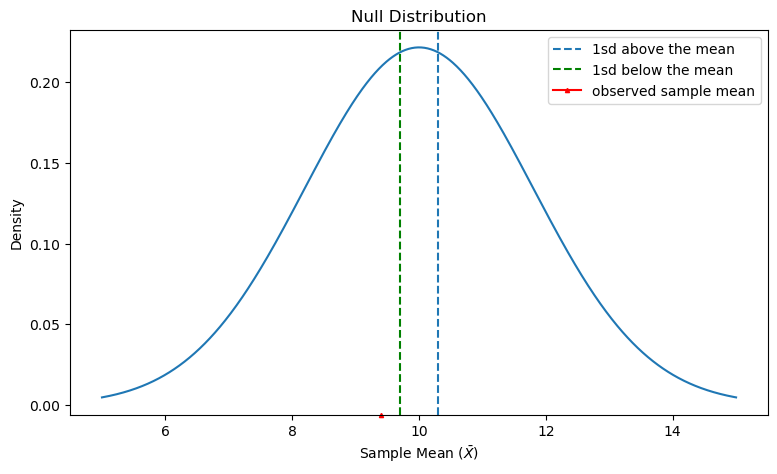

In [ ]:
z_values = np.linspace(5, 15, 1000)
density = norm.pdf(z_values, loc=10, scale=sigma)

plt.figure(figsize=(9, 5))
plt.plot(z_values, density)

plt.axvline(claim_mu + sample_std_deviation, linestyle="--", label="1sd above the mean")
plt.axvline(claim_mu - sample_std_deviation, linestyle="--", label="1sd below the mean", c = "green")
plt.plot(x_bar, 0, marker='^', color='red', markersize=3, label = "observed sample mean",
         transform=plt.gca().get_xaxis_transform(), clip_on=False)


plt.xlabel(r'Sample Mean ($\bar{X}$)')
plt.ylabel("Density")
plt.title("Null Distribution")
plt.legend()
plt.show()

In [16]:
discrepancy = x_bar - claim_mu
print(f"Our discrepancy is {np.abs(discrepancy/sample_std_deviation).round(1)} times of the standard deviation")

Our discrepancy is 2.0 times of the standard deviation


And we can check it again with standardizing our statistic into a z-score:

In [ ]:
z = (x_bar - claim_mu)/sample_std_deviation
z.round(2)

np.float64(-2.0)

If we standardize it, we would find ourselves being 2 standard errors below the mean!

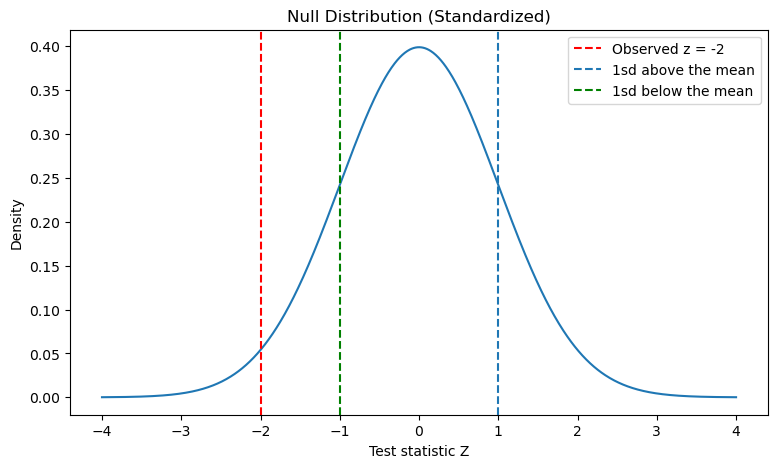

In [27]:
z_values = np.linspace(-4, 4, 1000)
density = norm.pdf(z_values)

plt.figure(figsize=(9, 5))
plt.plot(z_values, density)

plt.axvline(-2, linestyle="--", label="Observed z = -2", c = "red")
plt.axvline(1, linestyle="--", label="1sd above the mean")
plt.axvline(-1, linestyle="--", label="1sd below the mean", c = "green")

plt.xlabel("Test statistic Z")
plt.ylabel("Density")
plt.title("Null Distribution (Standardized)")
plt.legend()
plt.show()

**Attention:**     
1. All of the above is built on our assumption that **the company is telling the truth, i.e. , the true mean battery life is 10 hours.**    
2. **IF** we are treating #1 being true, **THEN** our sample mean **should** follow a normal distribution with mean = 10, variance = $\sigma^2/n$
3. **IF** we are treating #2 being true, then the test statistic (z-score) should follow a standard normal distribution.

### **Calculate the p-value**

Now that we have observed test statistic z = -2, what is the p-value asking?

Since our alternative hypothesis is
$H_1: \mu \leq 10$:    
Assuming the null hypothesis is true, how likely is it for us to get a z with, in our case, a value of -2 and even less?

In [29]:
p_value = norm.cdf(z)

print("p-value:", p_value)

p-value: 0.022750131948179285


We can also check the [z-table](https://www.ztable.net/) for the p-value.

#### Questions \#3: How should we interpret this p-value?

Your Answer:

Before conducting the test, let's choose a significance level:    
$\alpha = 0.05$

In [30]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


#### Question \#4: What are we really rejecting?

Your Answer:

### **Practice \#1:** 

A second company claims that the average battery life of its batteries is **100** hours. We randomly sampled **64** batteries and observed that the sample mean of battery life is **103**. Assume that the standard deviation of battery life is known, where $\sigma$ = **12**. We want to investigate whether the company is bragging about their product.  


**Work on the codes!**

In [ ]:
mu_0 = 100
x_bar = 103
sigma = 12
n = 64

# Fill in the blank!
sample_variance = 
z_score = 
p_value = 

Let's set the significance level to 0.05, what is our decision?

In [ ]:
alpha = 0.05

# What's next?

### **Practice \#2:**

A second company claims that the average battery life of its batteries is **100** hours. Three seperate teams did sampling experiments to test if the company is bragging about their product.  
First team sampled **16** batteries.  
Second team sampled **64** batteries.  
Third team sampled **256** batteries.  
And it turns out that all three experiments returned a sample mean of battery life is **103** (Which is probabily not likely in real life). Assume that the standard deviation of battery life is known, where $\sigma$ = **12**.  
Assuming that the significance level is 0.05, what are each team's opinion towards the company's claim?  
  
**Work on the codes!**

In [ ]:
mu_0 = 100
x_bar = 103
sigma = 12

n1 = 
n2 = 
n3 = 

sample_variance_1 =
sample_variance_2 =
sample_variance_3 =

z_score_1 = 
z_score_2 = 
z_score_3 = 

p_value_1 = 
p_value_2 = 
p_value_3 = 

alpha = 0.05
# What's next?

### **One-Sided, Two-Sided, and the Intuition**

For our motivating example, we started with the question:

**Is the true $\mu$ less than 10?**

That gives us the Null Hypothesis

$$
H_0:\mu=10
$$

and the Alternative Hypothesis

$$
H_1:\mu<10.
$$

We don't observe the true mean $\mu$ directly. We only observe the sample mean $\bar X$.

If the true mean really is 10, then we would expect our sample mean to be somewhere around 10, with some sampling variability. On the other hand, if the true mean is less than 10, then we would expect our sample mean to tend to be below 10.

So, because our alternative hypothesis is $\mu<10$, **smaller sample means are the kind of observations that would provide evidence in favor of the alternative hypothesis.**

But simply saying that a sample mean is "small" is not enough. A sample mean of 9.9 might be quite unusual if the sampling variability is very small, but completely unremarkable if the sampling variability is very large.

To account for this sampling variability, we standardize the sample mean using its standard error:

$$
Z=\frac{\bar X-\mu_0}{\sigma/\sqrt n}.
$$

In our example, $\mu_0=10$, so the test statistic tells us how many standard errors our observed sample mean is away from the value specified by the null hypothesis.

Suppose our sample gives us

$$
z=-2.
$$

This means that our observed sample mean is **2 standard errors below the value predicted by the null hypothesis**.

Now we can make the idea of "unusually small" precise.

Because our alternative hypothesis is

$$
H_1:\mu<10,
$$

we are interested in unusually small values of the test statistic. We have already observed $z=-2$, so we ask:

> **If the null hypothesis were true, how often would we obtain a test statistic of $-2$ or even lower?**

In other words, we are looking at

$$
P(Z\leq -2\mid H_0).
$$

Why do we include values even lower than $-2$?

Because they would be **at least as extreme in the direction specified by our alternative hypothesis**. If $z=-2$ is evidence that the mean might be below 10, then $z=-2.5$ or $z=-3$ would provide evidence in the same direction and would be even more unusual under the null hypothesis.

This probability is our **p-value**.

If the p-value is smaller than our chosen significance level, say $\alpha=0.05$, then our observed result falls into a region that would be sufficiently unusual under the null hypothesis. We therefore reject the null hypothesis.

For example, if

$$
P(Z\leq-2)=0.0228,
$$

then

$$
0.0228<0.05,
$$

so we reject $H_0$.

Importantly, this does **not** mean that the null hypothesis is impossible or that the true mean must be less than 10. Rather, it means that the data provide sufficient evidence against $H_0$, in the direction specified by $H_1$.

---

### What changes for a two-sided test?

Now suppose our question is:

**Is the true $\mu$ different from 10?**

Our hypotheses become

$$
H_0:\mu=10
$$

and

$$
H_1:\mu\neq10.
$$

Now we are interested in departures from 10 in **either direction**.

Our sample still gives us

$$
z=-2.
$$

We already know that a result of $-2$ is 2 standard errors below the null value. We therefore ask:

> **If the null hypothesis were true, how often would we obtain a result that is at least this far from the null value, in either direction?**

A result of $-2.5$ or $-3$ would be more extreme in the same direction.

But because our alternative hypothesis allows the true mean to be either **less than 10 or greater than 10**, a result of $+2.5$ or $+3$ would also be evidence against the null hypothesis. It is just as far from the null value, but in the opposite direction.

Therefore, for a two-sided test, we count both tails:

$$
P(Z\leq-2)+P(Z\geq2).
$$

Equivalently,

$$
P(|Z|\geq2).
$$

So the key difference is:

$$
\boxed{
H_1:\mu<10
\quad\Rightarrow\quad
\text{look for unusually small }Z
}
$$

while

$$
\boxed{
H_1:\mu\neq10
\quad\Rightarrow\quad
\text{look for unusually large }|Z|
}
$$

The alternative hypothesis therefore determines **what kinds of departures from the null hypothesis count as evidence**, and the observed test statistic tells us **how extreme our observed departure was**.


### Type I and Type II Errors

So far, we have used the hypothesis test to make a decision about the null hypothesis:

* **Reject $H_0$**, when the data provide sufficient evidence against it.
* **Fail to reject $H_0$**, when the data do not provide sufficient evidence against it.

But there is an important thing to remember:

> **We do not know whether the null hypothesis is actually true or false.**

We only observe our sample and use it to make a decision.

This means that there are four possible situations.

| Reality        | Our decision         | What happened?    |
| -------------- | -------------------- | ----------------- |
| $H_0$ is true  | Reject $H_0$         | **Type I error**  |
| $H_0$ is true  | Fail to reject $H_0$ | Correct decision  |
| $H_0$ is false | Reject $H_0$         | Correct decision  |
| $H_0$ is false | Fail to reject $H_0$ | **Type II error** |

A **Type I error** occurs when we reject the null hypothesis even though it is actually true.

For example, suppose

$$
H_0:\mu=10
$$

is actually true, but our particular sample happens to produce a sufficiently unusual result, so we reject $H_0$.

We have made a Type I error.

This is the error that our significance level $\alpha$ controls.

If we choose

$$
\alpha=0.05,
$$

then, under the assumptions of the test,

$$
P(\text{Type I error})=P(\text{reject }H_0\mid H_0\text{ is true})\leq0.05.
$$

For a test whose rejection region is calibrated exactly at $\alpha$, this probability is $\alpha$.

So $\alpha$ can be understood as the probability of making a Type I error **when the null hypothesis is true**.

---

A **Type II error** is the other possibility.

This occurs when the null hypothesis is actually false, but our sample does not provide enough evidence to reject it.

For example, suppose the true mean is actually

$$
\mu=9,
$$

but our sample happens to give a result that is not sufficiently unusual under

$$
H_0:\mu=10.
$$

We fail to reject $H_0$, even though it is false.

That is a Type II error.

We often denote its probability by

$$
\beta=P(\text{fail to reject }H_0\mid H_0\text{ is false}).
$$

The important distinction is:

$$
\boxed{
\alpha\text{ controls the probability of a Type I error}
}
$$

while

$$
\boxed{
\beta\text{ describes the probability of a Type II error}
}
$$

for a particular alternative value and test setup.


### Connecting Hypothesis Tests to Confidence Intervals

Now let's connect this back to confidence intervals.

Suppose we construct a 95% confidence interval for $\mu$.

For example, suppose our sample produces

$$
95\%\text{ CI}=[9.1,9.7].
$$

What does this interval tell us about the hypothesis

$$
H_0:\mu=10?
$$

Notice that $10$ is **not inside the confidence interval**.

This means that the value $\mu=10$ is not consistent with the range of values supported by this 95% confidence interval.

There is an equivalent way to think about this:

> A 95% confidence interval contains exactly the parameter values that would **not be rejected** by the corresponding two-sided hypothesis tests at the 5% significance level.

So if we test

$$
H_0:\mu=10
$$

against

$$
H_1:\mu\neq10
$$

at

$$
\alpha=0.05,
$$

then:

$$
\boxed{
10\notin95\%\text{ CI}
\quad\Longleftrightarrow\quad
\text{reject }H_0
}
$$

On the other hand, suppose our 95% confidence interval were

$$
[9.1,10.5].
$$

Now $10$ is inside the interval.

Therefore, the corresponding hypothesis test would **fail to reject**

$$
H_0:\mu=10.
$$

So:

$$
\boxed{
10\in95\%\text{ CI}
\quad\Longleftrightarrow\quad
\text{fail to reject }H_0
}
$$

---

### Why does this relationship exist?

Remember what the confidence interval is doing.

A 95% confidence interval is constructed from values of $\mu$ that are not too far from our observed sample result.

For every possible value $\mu_0$, we could ask:

> **If $\mu=\mu_0$, would our observed sample be unusually far away from $\mu_0$?**

If the answer is yes, then the hypothesis

$$
H_0:\mu=\mu_0
$$

would be rejected.

If the answer is no, then we would fail to reject it.

Therefore, we can imagine testing **every possible value of $\mu$**.

The values that we fail to reject form the confidence interval.

In other words:

$$
\boxed{
\text{Confidence interval}
=
\text{the collection of null values that are not rejected}
}
$$

for the corresponding two-sided test.

This gives us two ways of looking at essentially the same information:

**Hypothesis test:**

> "Is this particular value of $\mu$ compatible with the data?"

**Confidence interval:**

> "What range of values of $\mu$ are compatible with the data under this testing procedure?"

The hypothesis test gives us a decision about one particular value.

The confidence interval gives us the whole collection of values that would not be rejected.
